# AeroTwin — CWRU Fault Model Comparison
This notebook validates the predictive maintenance models (SVM, Random Forest, 1D CNN) for vibration-based fault classification using the CWRU dataset.

In [17]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Configuration
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CACHE_DIR = "data/cache"
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook")

## 01. Load Processed Cache
We load the engineered features (for SVM/RF) and raw vibration windows (for 1D CNN).

In [18]:
cache_path = os.path.join(CACHE_DIR, "cwru_processed.pkl")
with open(cache_path, "rb") as f:
    cache_data = pickle.load(f)

X_train_feat = cache_data['X_train_feat']
X_val_feat = cache_data['X_val_feat']
X_test_feat = cache_data['X_test_feat']

X_train_sig = cache_data['X_train_sig']
X_val_sig = cache_data['X_val_sig']
X_test_sig = cache_data['X_test_sig']

y_train = cache_data['y_train']
y_val = cache_data['y_val']
y_test = cache_data['y_test']

feature_names = cache_data['feature_names']

# Map string labels to integers for CNN
classes = np.unique(y_train)
class_map = {cls: i for i, cls in enumerate(classes)}
reverse_map = {i: cls for i, cls in enumerate(classes)}

y_train_idx = np.array([class_map[y] for y in y_train])
y_val_idx = np.array([class_map[y] for y in y_val])
y_test_idx = np.array([class_map[y] for y in y_test])

print(f"Loaded {len(X_train_feat)} train samples")
print(f"Classes: {class_map}")

Loaded 22723 train samples
Classes: {'Ball_Fault': 0, 'Inner_Race_Fault': 1, 'Normal': 2, 'Outer_Race_Fault_12': 3, 'Outer_Race_Fault_3': 4, 'Outer_Race_Fault_6': 5}


## 02. Preprocessing for Classical Models
Scale the engineered features using StandardScaler.

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled = scaler.transform(X_val_feat)
X_test_scaled = scaler.transform(X_test_feat)

## 03. Train Support Vector Machine (SVM)
A strong classical baseline.

In [20]:
print("Training SVM...")
svm_model = SVC(kernel='rbf', C=1.0, random_state=SEED)
svm_model.fit(X_train_scaled, y_train)

svm_val_preds = svm_model.predict(X_val_scaled)
svm_f1 = f1_score(y_val, svm_val_preds, average='macro')
print(f"SVM Validation Macro F1: {svm_f1:.4f}")

Training SVM...
SVM Validation Macro F1: 0.2021


## 04. Train Random Forest
Provides feature importance and handles non-linear interactions.

Training Random Forest...
Random Forest Validation Macro F1: 0.2025


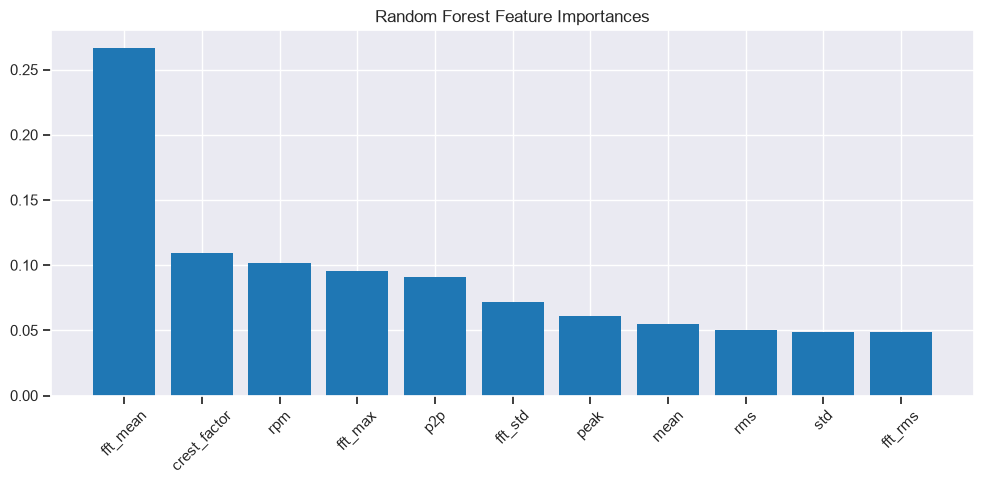

In [21]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

rf_val_preds = rf_model.predict(X_val_scaled)
rf_f1 = f1_score(y_val, rf_val_preds, average='macro')
print(f"Random Forest Validation Macro F1: {rf_f1:.4f}")

# Plot Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Random Forest Feature Importances")
plt.bar(range(X_train_feat.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train_feat.shape[1]), [feature_names[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

### 05: XGBoost
Let's test XGBoost on the tabular engineered features.

In [22]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

# XGBoost requires integer labels from 0 to num_classes-1
le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)
y_val_xgb = le.transform(y_val)
y_test_xgb = le.transform(y_test)

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train_scaled, y_train_xgb)

xgb_val_preds = xgb_model.predict(X_val_scaled)
xgb_val_acc = accuracy_score(y_val_xgb, xgb_val_preds)
xgb_val_f1 = f1_score(y_val_xgb, xgb_val_preds, average='macro')

print(f"XGBoost Val Accuracy: {xgb_val_acc:.4f}")
print(f"XGBoost Val Macro F1: {xgb_val_f1:.4f}")


XGBoost Val Accuracy: 0.2330
XGBoost Val Macro F1: 0.1621


## 06. Train 1D CNN
Learns features automatically from the raw vibration signal.

In [23]:
# CNN expects shape (samples, window_size, features)
X_train_cnn = np.expand_dims(X_train_sig, axis=-1)
X_val_cnn = np.expand_dims(X_val_sig, axis=-1)
X_test_cnn = np.expand_dims(X_test_sig, axis=-1)

num_classes = len(classes)
WINDOW_SIZE = X_train_cnn.shape[1]

cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=64, activation='relu', input_shape=(WINDOW_SIZE, 1)),
    MaxPooling1D(pool_size=4),
    Conv1D(filters=64, kernel_size=32, activation='relu'),
    MaxPooling1D(pool_size=4),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

c:\Users\mohit\Documents\AeroTwin\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 961, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 240, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 209, 64)        │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 52, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3328)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       426,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 494,566 (1.89 MB)

 Trainable params: 494,566 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Training 1D CNN...")
history = cnn_model.fit(
    X_train_cnn, y_train_idx,
    validation_data=(X_val_cnn, y_val_idx),
    epochs=30,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

cnn_val_preds_prob = cnn_model.predict(X_val_cnn, verbose=0)
cnn_val_preds_idx = np.argmax(cnn_val_preds_prob, axis=1)
cnn_val_preds = np.array([reverse_map[i] for i in cnn_val_preds_idx])

cnn_f1 = f1_score(y_val, cnn_val_preds, average='macro')
print(f"1D CNN Validation Macro F1: {cnn_f1:.4f}")

Training 1D CNN...
Epoch 1/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.5135 - loss: 1.1574 - val_accuracy: 0.6360 - val_loss: 0.9407
Epoch 2/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.8124 - loss: 0.5102 - val_accuracy: 0.7451 - val_loss: 0.7480
Epoch 3/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.8907 - loss: 0.3056 - val_accuracy: 0.7612 - val_loss: 0.7031
Epoch 4/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9229 - loss: 0.2206 - val_accuracy: 0.8168 - val_loss: 0.6683
Epoch 5/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9365 - loss: 0.1803 - val_accuracy: 0.7971 - val_loss: 0.8492
Epoch 6/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9519 - loss: 0.1401 - val_accuracy: 0.7693 - val_loss: 1.0398
Epoch 7/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9626 - loss: 0.1094 - val_accuracy: 0.7860 - val_loss: 1.0337
Epoch 8/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9695 - loss: 0.0908 - val_a

## 07. Model Comparison & Test Set Evaluation
We compare the validation performance and then evaluate the best model on the untouched test set.

In [28]:
results = [
    {"Model": "SVM", "Val Macro F1": svm_f1},
    {"Model": "Random Forest", "Val Macro F1": rf_f1},
    {"Model": "1D CNN", "Val Macro F1": cnn_f1},
    {"Model": "XGBoost", "Val Macro F1": xgb_val_f1}
]

comp_df = pd.DataFrame(results).sort_values("Val Macro F1", ascending=False)
display(comp_df)

# Best Model Evaluation
best_model_name = comp_df.iloc[0]["Model"]
print(f"\\nSelected Best Model: {best_model_name}")

if best_model_name == "1D CNN":
    test_preds_idx = np.argmax(cnn_model.predict(X_test_cnn, verbose=0), axis=1)
    test_preds = np.array([reverse_map[i] for i in test_preds_idx])
elif best_model_name == "XGBoost":
    test_preds_xgb = xgb_model.predict(X_test_scaled)
    test_preds = le.inverse_transform(test_preds_xgb)
elif best_model_name == "Random Forest":
    test_preds = rf_model.predict(X_test_scaled)
else:
    test_preds = svm_model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, test_preds)
test_prec = precision_score(y_test, test_preds, average='macro')
test_rec = recall_score(y_test, test_preds, average='macro')
test_f1 = f1_score(y_test, test_preds, average='macro')
test_weighted_f1 = f1_score(y_test, test_preds, average='weighted')

print(f"\\n--- Test Set Metrics ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"Macro Precision: {test_prec:.4f}")
print(f"Macro Recall: {test_rec:.4f}")
print(f"Macro F1: {test_f1:.4f}")
print(f"Weighted F1: {test_weighted_f1:.4f}")

,Model,Val Macro F1
2,1D CNN,0.746405
1,Random Forest,0.202548
0,SVM,0.202136
3,XGBoost,0.162070


\nSelected Best Model: 1D CNN
\n--- Test Set Metrics ---
Accuracy: 0.8076
Macro Precision: 0.8026
Macro Recall: 0.8018
Macro F1: 0.7963
Weighted F1: 0.8082


## 08. Confusion Matrix

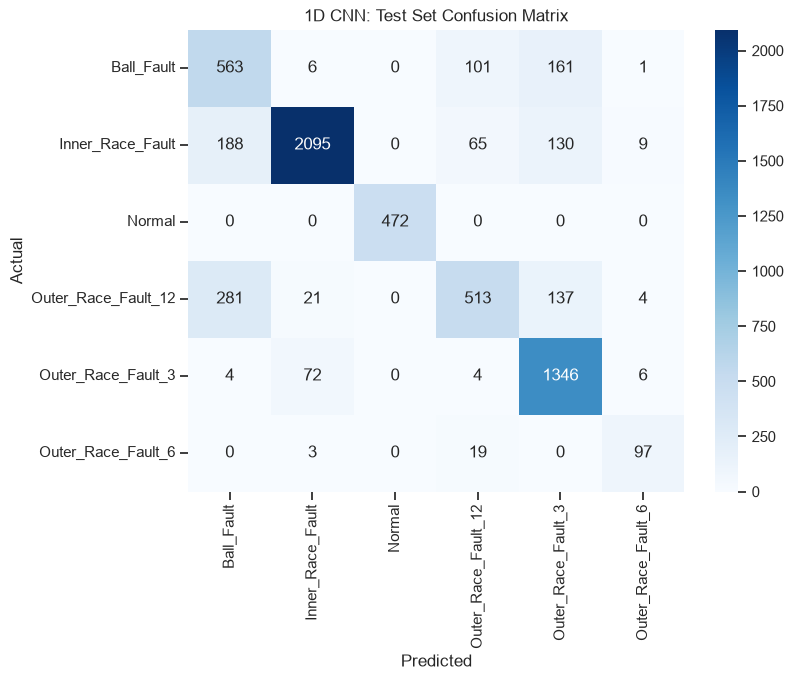

In [26]:
cm = confusion_matrix(y_test, test_preds, labels=classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title(f"{best_model_name}: Test Set Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 09. Save Final Artifacts

In [27]:
if best_model_name == "1D CNN":
    cnn_model.save(os.path.join(MODELS_DIR, "best_cwru_model.keras"))
elif best_model_name == "Random Forest":
    with open(os.path.join(MODELS_DIR, "best_cwru_model.pkl"), "wb") as f:
        pickle.dump(rf_model, f)
else:
    with open(os.path.join(MODELS_DIR, "best_cwru_model.pkl"), "wb") as f:
        pickle.dump(svm_model, f)
        
print("Pipeline complete!")

Pipeline complete!
